# Customer Analytics with DuckDB SQL

This notebook explores customer purchasing behavior and customer value metrics using DuckDB and SQL analytics.

Main business questions:
- Which customers generate the highest lifetime value?
- What is the average order value across the business?
- How many customers are repeat buyers?
- How concentrated is customer revenue distribution?
- What customer behavior patterns can be identified?

Key topics:
- Customer Lifetime Value (CLV)
- Average Order Value (AOV)
- Repeat customer analysis
- Customer segmentation
- Distribution analysis
- SQL aggregations and CTEs

## Customer Lifetime Value (CLV)

Customer Lifetime Value measures the total revenue generated by each customer across all purchases.

This analysis helps identify:
- High-value customers
- Revenue concentration
- Customer spending behavior
- Potential VIP customer segments

In [11]:
##Imports
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [12]:
##Creating the connection
conn = duckdb.connect("../ecommerce.duckdb")

In [13]:
customer_clv_df = conn.execute("""
SELECT
    o.customer_id,
    ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS customer_lifetime_value
FROM fact_order_items f
JOIN orders o
ON f.order_id = o.order_id
GROUP BY o.customer_id
ORDER BY customer_lifetime_value DESC
""").df()

customer_clv_df.head()

,customer_id,customer_lifetime_value
0,433,71080.78
1,615,63983.17
2,465,61623.09
3,144,57346.73
4,711,53539.57


### CLV Distribution

The following visualization shows how customer lifetime value is distributed across the customer base.

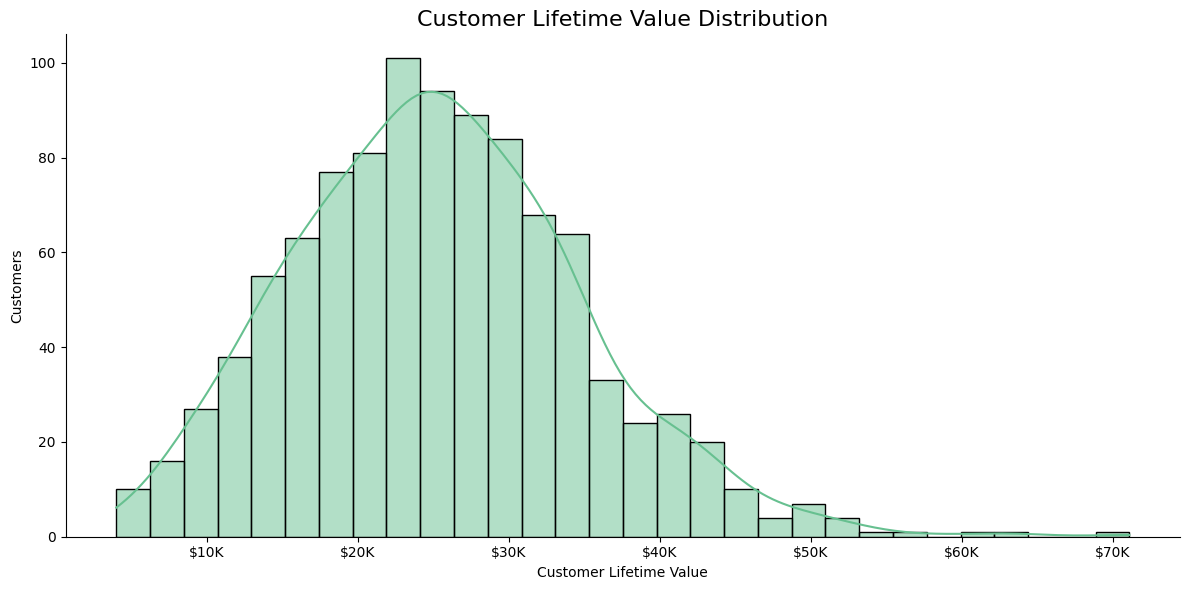

In [14]:
plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=customer_clv_df,
    x="customer_lifetime_value",
    bins=30,
    kde=True,
    color= "#67C090"
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'${x/1_000:.0f}K'
    )
)

plt.title(
    "Customer Lifetime Value Distribution",
    fontsize=16
)

plt.xlabel("Customer Lifetime Value")
plt.ylabel("Customers")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/customer_lifetime_value_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Most customers generate relatively low lifetime value.
- A small percentage of customers contribute disproportionately to total revenue.
- The distribution appears right-skewed, which is common in ecommerce businesses.

# Average Order Value (AOV)

Average Order Value measures the average revenue generated per order.

This metric helps evaluate:
- Customer purchasing behavior
- Pricing effectiveness
- Overall transaction size

In [15]:
aov_df = conn.execute("""
WITH order_totals AS (
    SELECT
        order_id,
        ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS order_value
    FROM fact_order_items
    GROUP BY order_id
)

    SELECT
    ROUND(AVG(order_value), 2) AS average_order_value
    FROM order_totals
""").df()

aov_df

,average_order_value
0,2532.82


### Average Order Value KPI

In [16]:
aov_value = aov_df.iloc[0,0]

print(f"Average Order Value: ${aov_value:,.2f}")

Average Order Value: $2,532.82


### Key Insights

- The average order value provides a benchmark for customer spending per transaction.
- Large order variability may indicate diverse purchasing behavior across customers.

# Repeat Customer Analysis

Repeat customers are users who placed more than one order.

This analysis helps measure:
- Customer retention
- Customer loyalty
- Returning purchase behavior

In [17]:
repeat_customers_df = conn.execute("""
WITH customer_orders AS (
    SELECT
    customer_id,
    COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY customer_id
)

SELECT
    COUNT(CASE WHEN total_orders > 1 THEN 1 END) AS repeat_customers,
    COUNT(*) AS total_customers,
    ROUND(COUNT(CASE WHEN total_orders > 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS repeat_customer_rate
FROM customer_orders
""").df()

repeat_customers_df

,repeat_customers,total_customers,repeat_customer_rate
0,1000,1000,100.0


### Customer Segmentation by Number of Orders

This analysis groups customers according to their purchasing frequency.

In [18]:
customer_segments_df = conn.execute("""
WITH customer_orders AS (
    SELECT
    customer_id,
    COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY customer_id
)

SELECT
    CASE 
        WHEN total_orders = 1 THEN '1 order'
        WHEN total_orders BETWEEN 2 AND 5 THEN '2-5 orders'
        ELSE '6+ orders' END AS customer_segment,
    COUNT(*) AS total_customers
FROM customer_orders
GROUP BY customer_segment
ORDER BY total_customers DESC
""").df()

customer_segments_df

,customer_segment,total_customers
0,6+ orders,929
1,2-5 orders,71


C:\Users\spavone\AppData\Local\Temp\ipykernel_7120\1678234348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


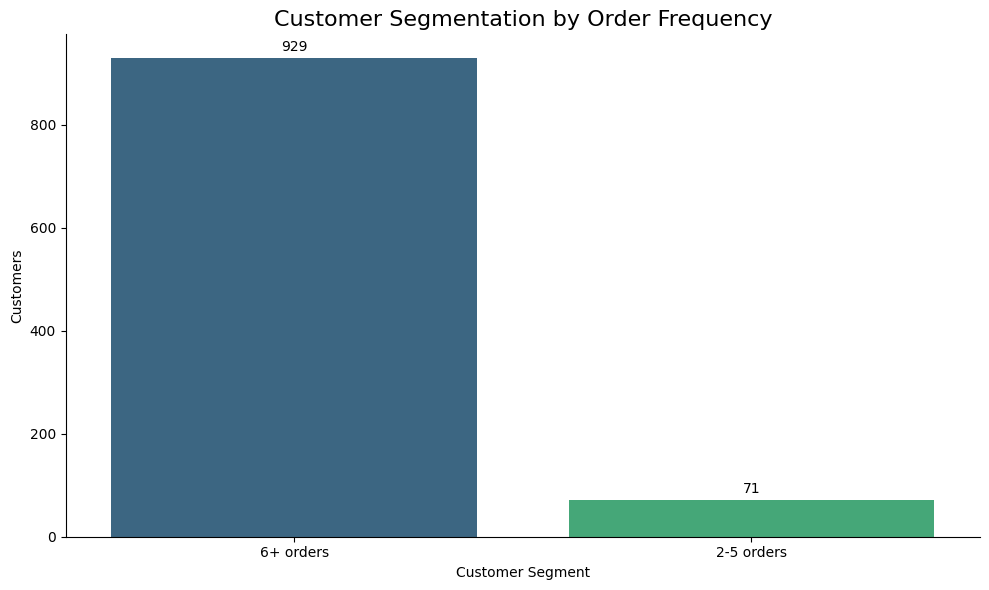

In [19]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=customer_segments_df,
    x="customer_segment",
    y="total_customers",
    palette="viridis",
    edgecolor="none"
)

for container in ax.containers:

    labels = [
        f'{int(v.get_height()):,}'
        for v in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.title(
    "Customer Segmentation by Order Frequency",
    fontsize=16
)

plt.xlabel("Customer Segment")
plt.ylabel("Customers")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/customer_segmentation_by_order_frequency.png",
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Repeat customers represent a key source of recurring revenue.
- A strong repeat purchase rate may indicate healthy customer retention.
- Understanding repeat behavior is critical for long-term business growth.